In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [2]:
word_categories = {
    "fruit": ["apple", "banana", "orange", "grape", "mango"],
    "animal": ["dog", "cat", "lion", "tiger", "elephant"],
    "vehicle": ["car", "bus", "bike", "train", "airplane"],
}

In [3]:
embedding_dim = 128
word_embeddings = {}

In [4]:
np.random.seed(42)

In [6]:
for category,words in word_categories.items():
  center = np.random.rand(embedding_dim) * 2.0
  for word in words:
    word_embeddings[word] = center + np.random.normal(0,0.25,embedding_dim)

In [13]:
def generate_positional_encodings(seq_len, dim) -> np.array:
  # Corrected to np.zeros
  pe = np.zeros((seq_len, dim))

  for pos in range(seq_len):
    for i in range(0, dim, 2):
      # Standard Transformer positional encoding formula
      divisor = np.power(10000, (2 * i) / dim)

      pe[pos, i] = np.sin(pos / divisor)

      if i + 1 < dim:
        pe[pos, i + 1] = np.cos(pos / divisor)

  return pe

In [14]:
seq_len = 15
embedding_dim = 128
words = list(word_embeddings.keys())
seq_len = len(words)
pe_matrix = generate_positional_encodings(seq_len, embedding_dim)
print(f"Positional encoding matrix shape: {pe_matrix.shape}")

Positional encoding matrix shape: (15, 128)


In [15]:
combined_embeddings = {}
for idx, word in enumerate(words):
    combined_embeddings[word] = word_embeddings[word] + pe_matrix[idx]

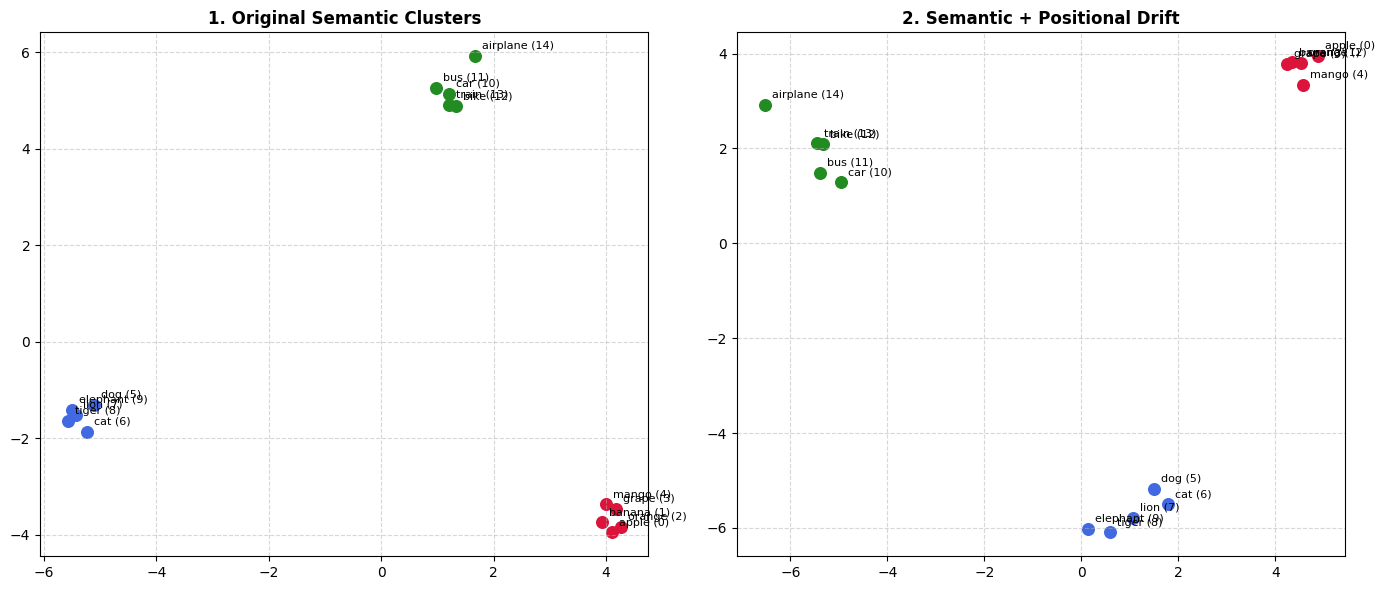

In [16]:
pca = PCA(n_components=2)
reduced_orig = pca.fit_transform(np.array(list(word_embeddings.values())))
reduced_comb = pca.fit_transform(np.array(list(combined_embeddings.values())))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors = {"fruit": "crimson", "animal": "royalblue", "vehicle": "forestgreen"}


def get_color(word):
    for cat, members in word_categories.items():
        if word in members:
            return colors[cat]
    return "gray"


for ax, data, title in zip(
    axes,
    [reduced_orig, reduced_comb],
    ["1. Original Semantic Clusters", "2. Semantic + Positional Drift"],
):
    for i, word in enumerate(words):
        color = get_color(word)
        ax.scatter(data[i, 0], data[i, 1], color=color, s=70)
        ax.annotate(
            f"{word} ({i})",
            (data[i, 0], data[i, 1]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )
    ax.set_title(title, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()